# Baseline vs Half-Life Regression

Сравниваем эвристический baseline (Leitner-style, аппроксимация SM-2) с обученной моделью Half-Life Regression по MAE предсказанной вероятности вспоминания.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

import baseline
from features import LexemeDifficultyEncoder, add_half_life_target, build_features
from train import train_test_split_by_user, recall_from_half_life
from sklearn.linear_model import Ridge


In [2]:
df = pd.read_csv("../data/sample.csv")
df = add_half_life_target(df)
train_df, test_df = train_test_split_by_user(df)

lexeme_encoder = LexemeDifficultyEncoder().fit(train_df)
x_train = build_features(train_df, lexeme_encoder)
x_test = build_features(test_df, lexeme_encoder).reindex(columns=x_train.columns, fill_value=0.0)

model = Ridge(alpha=1.0)
model.fit(x_train, np.log2(train_df["half_life"]))


,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [3]:
pred_hl = np.exp2(model.predict(x_test))
pred_recall_hlr = recall_from_half_life(pred_hl, test_df["delta_days"])
pred_recall_baseline = baseline.predict_recall(test_df)

mae_hlr = mean_absolute_error(test_df["p_recall"], pred_recall_hlr)
mae_baseline = mean_absolute_error(test_df["p_recall"], pred_recall_baseline)

pd.DataFrame({
    "model": ["Leitner-style baseline", "Half-Life Regression"],
    "MAE (p_recall)": [mae_baseline, mae_hlr],
})


,model,MAE (p_recall)
0,Leitner-style baseline,0.221743
1,Half-Life Regression,0.153988


## Веса признаков HLR

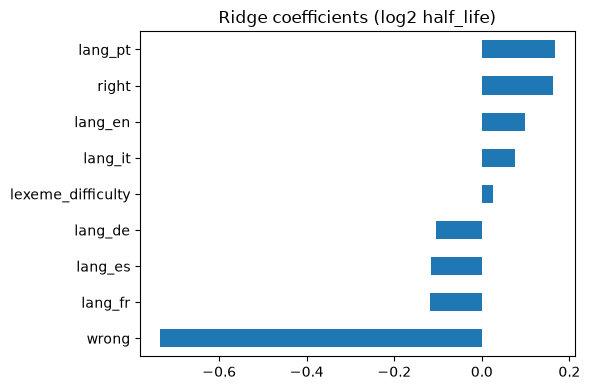

In [4]:
coef = pd.Series(model.coef_, index=x_train.columns).sort_values()
coef.plot(kind="barh", figsize=(6, 4), title="Ridge coefficients (log2 half_life)")
plt.tight_layout()


## Гистограмма ошибок предсказания (HLR вс baseline)

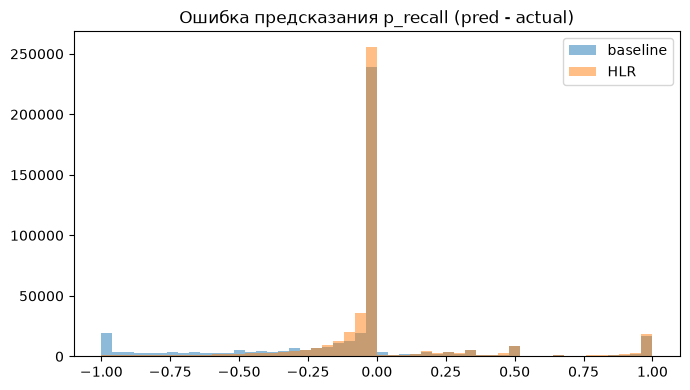

In [5]:
err_hlr = pred_recall_hlr - test_df["p_recall"]
err_baseline = pred_recall_baseline - test_df["p_recall"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(err_baseline, bins=50, alpha=0.5, label="baseline")
ax.hist(err_hlr, bins=50, alpha=0.5, label="HLR")
ax.set_title("\u041e\u0448\u0438\u0431\u043a\u0430 \u043f\u0440\u0435\u0434\u0441\u043a\u0430\u0437\u0430\u043d\u0438\u044f p_recall (pred - actual)")
ax.legend()
plt.tight_layout()


## Выводы

- HLR на сэмпле заметно точнее эвристического baseline по MAE.
- Знаки коэффициентов совпадают с ожиданием: больше правильных ответов → длиннее half-life, больше ошибок → короче.
- Следующий шаг: попробовать LightGBM вместо Ridge, затем обучить финальную модель на полном датасете (`python src/train.py --data data/settles.acl16.learning_traces.13m.csv`).